In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pymc as pm
import arviz as az
from scipy.special import expit, logit
from scipy.stats import binom
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
np.random.seed(42)
COLORS = {'train': '#2196F3', 'test': '#F44336', 'model': '#4CAF50', 'baseline': '#FF9800'}
print("Setup complete")

Setup complete


In [2]:
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])
tgt = tgt.sort_values('date').reset_index(drop=True)
tgt_clean = tgt[['date','month_sin','doy_cos','n_total','n_low','frac_low']].dropna()
tgt_clean = tgt_clean[tgt_clean['n_total'] >= 2].copy()

# Compute persistence feature: logit(frac_low_prev) if prev obs <= 3 days ago
tgt_clean['persistence'] = 0.0
for i in range(1, len(tgt_clean)):
    days_gap = (tgt_clean['date'].iloc[i] - tgt_clean['date'].iloc[i-1]).days
    if days_gap <= 3:
        prev_frac = tgt_clean['frac_low'].iloc[i-1]
        prev_frac = np.clip(prev_frac, 0.01, 0.99)
        tgt_clean.iloc[i, tgt_clean.columns.get_loc('persistence')] = logit(prev_frac)

# Train/test split: 80/20 chronological
split_idx = int(len(tgt_clean) * 0.8)
train = tgt_clean.iloc[:split_idx].copy()
test = tgt_clean.iloc[split_idx:].copy()
print(f"Train: {len(train)} days ({train.date.min().date()} to {train.date.max().date()})")
print(f"Test:  {len(test)} days ({test.date.min().date()} to {test.date.max().date()})")
print(f"Train frac_low mean: {train.frac_low.mean():.3f}")
print(f"Test  frac_low mean: {test.frac_low.mean():.3f}")

Train: 548 days (2021-07-12 to 2025-06-11)
Test:  137 days (2025-06-12 to 2026-01-27)
Train frac_low mean: 0.179
Test  frac_low mean: 0.080


In [3]:
try:
    src_post = pd.read_csv(DATA_DIR + 'nb07v2_source_posterior.csv')
    src_post = src_post.set_index('param')
    ms_mean = float(src_post.loc['month_sin', 'pymc_mean'])
    ms_std = float(src_post.loc['month_sin', 'pymc_std'])
    dc_mean = float(src_post.loc['doy_cos', 'pymc_mean'])
    dc_std = float(src_post.loc['doy_cos', 'pymc_std'])
    print(f"Source prior month_sin: {ms_mean:.3f} +/- {ms_std:.3f}")
    print(f"Source prior doy_cos:   {dc_mean:.3f} +/- {dc_std:.3f}")
except Exception as e:
    print(f"Using defaults: {e}")
    ms_mean, ms_std = 0.357, 0.086
    dc_mean, dc_std = 0.264, 0.085

a0 = 0.3  # optimal transfer strength from NB07
ms_prior_std = ms_std / np.sqrt(a0)
dc_prior_std = dc_std / np.sqrt(a0)
print(f"Power prior (a0={a0}) month_sin std: {ms_prior_std:.3f}")
print(f"Power prior (a0={a0}) doy_cos std:   {dc_prior_std:.3f}")

Source prior month_sin: 0.768 +/- 0.574
Source prior doy_cos:   0.759 +/- 0.663
Power prior (a0=0.3) month_sin std: 1.049
Power prior (a0=0.3) doy_cos std:   1.211


In [4]:
feat_cols = ['month_sin', 'doy_cos', 'persistence']
feat_mean = train[feat_cols].mean()
feat_std = train[feat_cols].std().replace(0, 1)

X_train = ((train[feat_cols] - feat_mean) / feat_std).values
X_test = ((test[feat_cols] - feat_mean) / feat_std).values

n_train = train['n_total'].values.astype(int)
k_train = train['n_low'].values.astype(int)
n_test = test['n_total'].values.astype(int)
k_test = test['n_low'].values.astype(int)
y_test_true = test['frac_low'].values

ms_prior_mean_std = ms_mean * feat_std['month_sin']
dc_prior_mean_std = dc_mean * feat_std['doy_cos']
ms_prior_std_std = ms_prior_std * feat_std['month_sin']
dc_prior_std_std = dc_prior_std * feat_std['doy_cos']

print("Feature standardization stats:")
print(feat_mean)
print(feat_std)
print(f"X_train shape: {X_train.shape}")

Feature standardization stats:
month_sin      0.115107
doy_cos        0.097284
persistence   -2.325656
dtype: float64
month_sin      0.708062
doy_cos        0.682124
persistence    2.583804
dtype: float64
X_train shape: (548, 3)


In [5]:
import pytensor.tensor as pt

with pm.Model() as bbsar1_model:
    intercept = pm.Normal('intercept', 0, 5)
    b_month_sin = pm.Normal('b_month_sin', mu=ms_prior_mean_std, sigma=ms_prior_std_std)
    b_doy_cos   = pm.Normal('b_doy_cos',   mu=dc_prior_mean_std, sigma=dc_prior_std_std)
    phi = pm.TruncatedNormal('phi', mu=0.3, sigma=0.2, lower=-0.9, upper=0.9)
    kappa = pm.Lognormal('kappa', mu=np.log(2.03), sigma=0.5)

    eta = (intercept
           + b_month_sin * X_train[:, 0]
           + b_doy_cos   * X_train[:, 1]
           + phi          * X_train[:, 2])

    mu = pm.math.sigmoid(eta)

    y_obs = pm.BetaBinomial('y_obs',
                             alpha=mu * kappa,
                             beta=(1 - mu) * kappa,
                             n=n_train,
                             observed=k_train)

    trace = pm.sample(
        draws=1500, tune=1500, chains=4,
        target_accept=0.9,
        progressbar=False,
        return_inferencedata=True
    )

print("Sampling complete.")
print(az.summary(trace, var_names=['intercept','b_month_sin','b_doy_cos','phi','kappa']))
summary_stats = az.summary(trace)
print()
print(f"Max R-hat: {summary_stats.r_hat.max():.4f}")
print(f"Min ESS:   {summary_stats.ess_bulk.min():.0f}")
print(f"Divergences: {trace.sample_stats.diverging.sum().item()}")

Initializing NUTS using jitter+adapt_diag...


ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.InplaceElemwiseOptimizer object at 0x115353230>


ERROR (pytensor.graph.rewriting.basic): Traceback:


ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/dlau/repos/fish-welfare/.venv/lib/python3.14/site-packages/pytensor/graph/features.py", line 643, in validate_
    ret = fgraph.execute_callbacks("validate")
  File "/Users/dlau/repos/fish-welfare/.venv/lib/python3.14/site-packages/pytensor/graph/fg.py", line 721, in execute_callbacks
    fn(self, *args, **kwargs)
    ~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dlau/repos/fish-welfare/.venv/lib/python3.14/site-packages/pytensor/graph/destroyhandler.py", line 677, in validate
    raise InconsistencyError("Dependency graph contains cycles")
pytensor.graph.utils.InconsistencyError: Dependency graph contains cycles

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/dlau/repos/fish-welfare/.venv/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/Users/dlau/re

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, b_month_sin, b_doy_cos, phi, kappa]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 2 seconds.


Sampling complete.
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept   -1.676  0.091  -1.850   -1.509      0.001    0.001    5430.0   
b_month_sin -0.339  0.084  -0.491   -0.177      0.001    0.001    6050.0   
b_doy_cos   -0.102  0.085  -0.263    0.056      0.001    0.001    6287.0   
phi          0.452  0.075   0.320    0.597      0.001    0.001    6133.0   
kappa        1.525  0.214   1.142    1.924      0.003    0.003    6238.0   

             ess_tail  r_hat  
intercept      4618.0    1.0  
b_month_sin    4570.0    1.0  
b_doy_cos      4538.0    1.0  
phi            4134.0    1.0  
kappa          4977.0    1.0  

Max R-hat: 1.0000
Min ESS:   5430
Divergences: 0


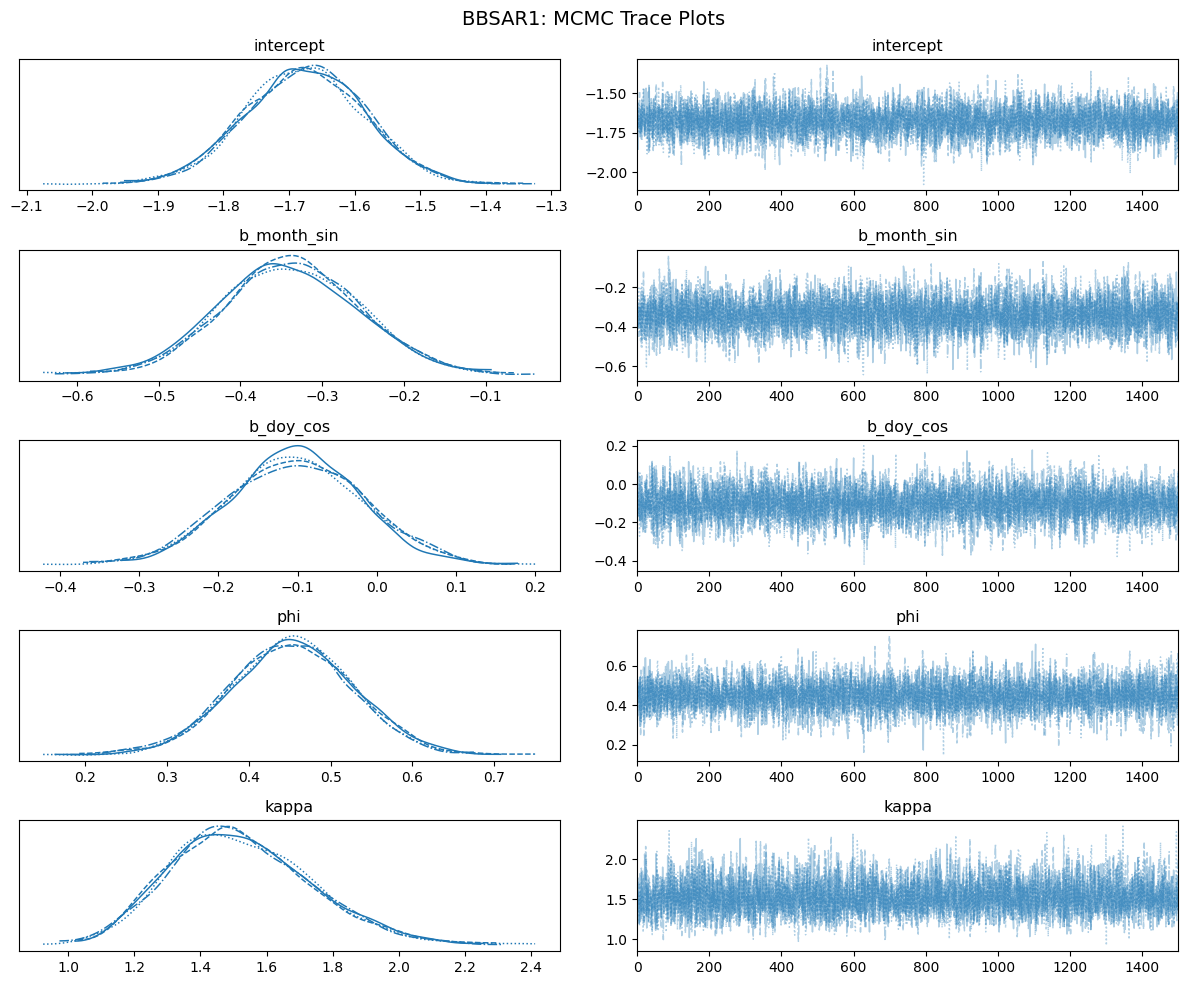

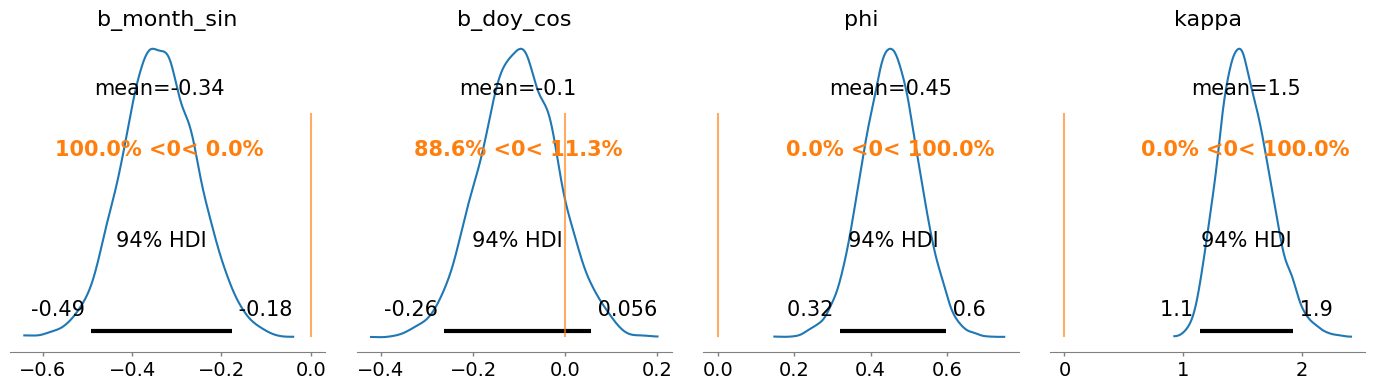

              mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
intercept   -1.676  0.091  -1.850   -1.509    1.0    5430.0
b_month_sin -0.339  0.084  -0.491   -0.177    1.0    6050.0
b_doy_cos   -0.102  0.085  -0.263    0.056    1.0    6287.0
phi          0.452  0.075   0.320    0.597    1.0    6133.0
kappa        1.525  0.214   1.142    1.924    1.0    6238.0


In [6]:
var_names = ['intercept', 'b_month_sin', 'b_doy_cos', 'phi', 'kappa']
axes = az.plot_trace(trace, var_names=var_names, combined=False, figsize=(12, 10))
plt.suptitle('BBSAR1: MCMC Trace Plots', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_trace_plots.png', dpi=80, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(1, 4, figsize=(14, 4))
az.plot_posterior(trace, var_names=['b_month_sin', 'b_doy_cos', 'phi', 'kappa'],
                  ref_val=0, ax=axes2)
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_posterior.png', dpi=80, bbox_inches='tight')
plt.show()

summary_df = az.summary(trace, var_names=['intercept','b_month_sin','b_doy_cos','phi','kappa'])
print(summary_df[['mean','sd','hdi_3%','hdi_97%','r_hat','ess_bulk']])

Sampling: [y_obs]


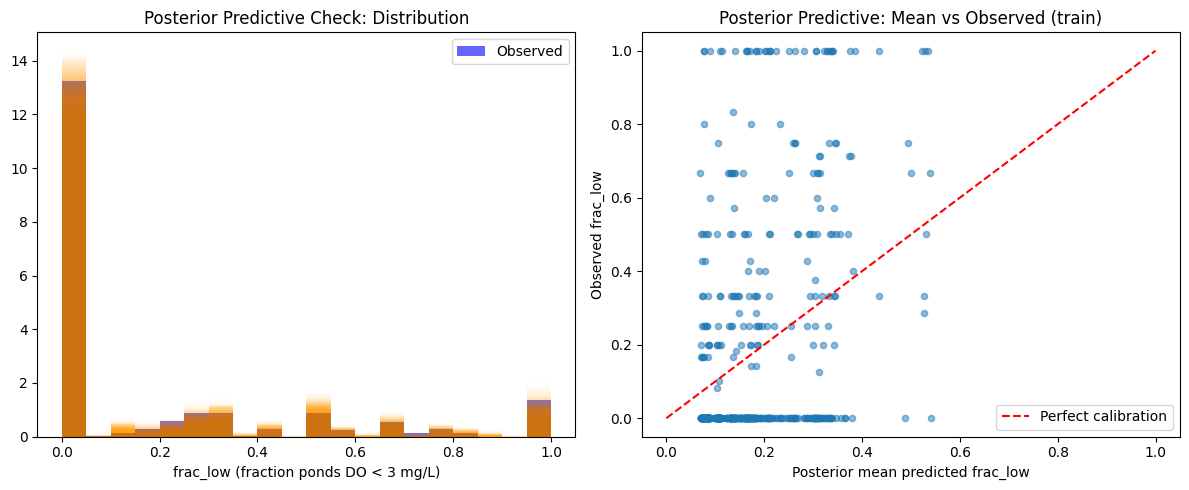

In [7]:
with bbsar1_model:
    ppc = pm.sample_posterior_predictive(trace, progressbar=False)

obs_frac = k_train / n_train
ppc_vals = ppc.posterior_predictive['y_obs'].values
ppc_frac = ppc_vals / n_train[None, None, :]
ppc_frac_flat = ppc_frac.reshape(-1, len(k_train))
ppc_mean = ppc_frac_flat.mean(0)
ppc_q05  = np.quantile(ppc_frac_flat, 0.05, axis=0)
ppc_q95  = np.quantile(ppc_frac_flat, 0.95, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(obs_frac, bins=20, alpha=0.6, color='blue', label='Observed', density=True)
for i in range(min(100, ppc_frac_flat.shape[0])):
    axes[0].hist(ppc_frac_flat[i], bins=20, alpha=0.02, color='orange', density=True)
axes[0].set_xlabel('frac_low (fraction ponds DO < 3 mg/L)')
axes[0].set_title('Posterior Predictive Check: Distribution')
axes[0].legend()
axes[1].scatter(ppc_mean, obs_frac, alpha=0.5, s=20)
axes[1].plot([0,1],[0,1],'r--', label='Perfect calibration')
axes[1].set_xlabel('Posterior mean predicted frac_low')
axes[1].set_ylabel('Observed frac_low')
axes[1].set_title('Posterior Predictive: Mean vs Observed (train)')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_ppc.png', dpi=80, bbox_inches='tight')
plt.show()

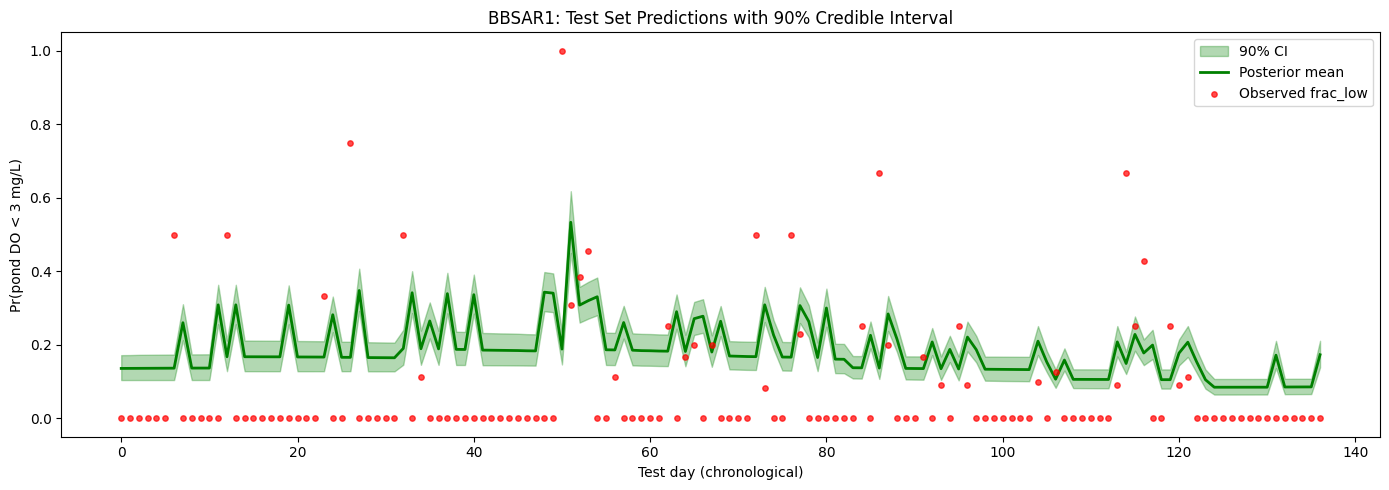

In [8]:
beta_ms = trace.posterior['b_month_sin'].values.flatten()
beta_dc = trace.posterior['b_doy_cos'].values.flatten()
phi_s   = trace.posterior['phi'].values.flatten()
int_s   = trace.posterior['intercept'].values.flatten()
kappa_s = trace.posterior['kappa'].values.flatten()

eta_test_samples = (int_s[:, None]
                    + beta_ms[:, None] * X_test[:, 0]
                    + beta_dc[:, None] * X_test[:, 1]
                    + phi_s[:, None]   * X_test[:, 2])
mu_test_samples = expit(eta_test_samples)

mu_test_mean  = mu_test_samples.mean(0)
mu_test_lower = np.quantile(mu_test_samples, 0.05, axis=0)
mu_test_upper = np.quantile(mu_test_samples, 0.95, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(test)), mu_test_lower, mu_test_upper,
                alpha=0.3, color='green', label='90% CI')
ax.plot(mu_test_mean, color='green', lw=2, label='Posterior mean')
ax.scatter(range(len(test)), y_test_true, color='red', s=15, alpha=0.7,
           label='Observed frac_low', zorder=5)
ax.set_xlabel('Test day (chronological)')
ax.set_ylabel('Pr(pond DO < 3 mg/L)')
ax.set_title('BBSAR1: Test Set Predictions with 90% Credible Interval')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_test_predictions.png', dpi=80, bbox_inches='tight')
plt.show()

Raw BBSAR1: Brier=0.0455, AUC=0.4601, Log-loss=0.3166
Calibrated BBSAR1: Brier=0.0512, AUC=0.4240, Log-loss=0.3321


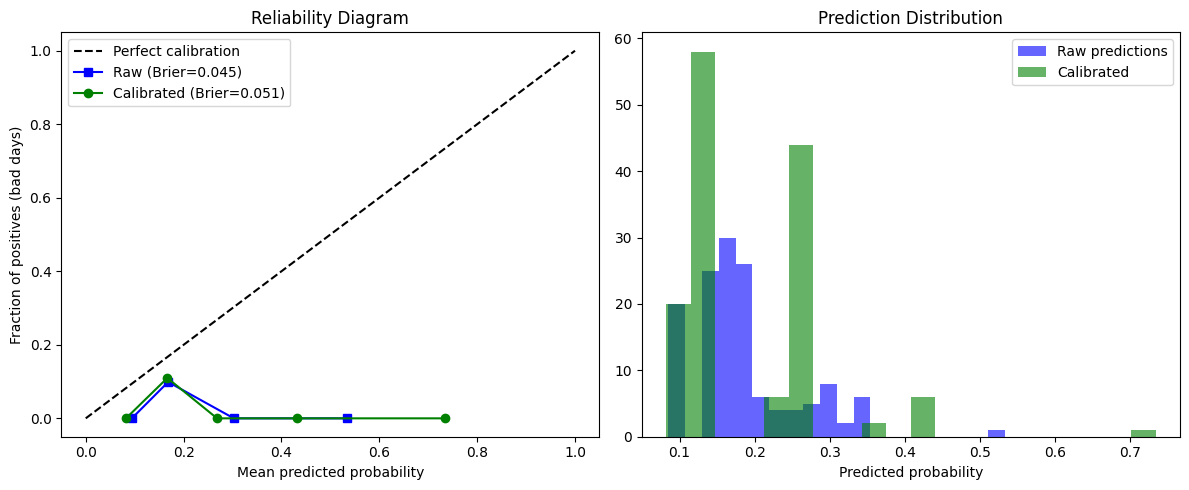

In [9]:
from sklearn.isotonic import IsotonicRegression

bad_day_test = (y_test_true >= 0.5).astype(int)
bad_day_test_soft = y_test_true

brier_raw = np.mean((mu_test_mean - bad_day_test_soft)**2)
try:
    auc_raw = roc_auc_score(bad_day_test, mu_test_mean)
except Exception:
    auc_raw = float('nan')
ll_raw = log_loss(bad_day_test, np.clip(mu_test_mean, 1e-6, 1-1e-6))

print(f"Raw BBSAR1: Brier={brier_raw:.4f}, AUC={auc_raw:.4f}, Log-loss={ll_raw:.4f}")

ir = IsotonicRegression(out_of_bounds='clip')
eta_train_mean = (int_s.mean() + beta_ms.mean() * X_train[:, 0]
                  + beta_dc.mean() * X_train[:, 1] + phi_s.mean() * X_train[:, 2])
mu_train_mean = expit(eta_train_mean)
ir.fit(mu_train_mean, k_train / n_train)
mu_test_cal = ir.predict(mu_test_mean)

brier_cal = np.mean((mu_test_cal - bad_day_test_soft)**2)
try:
    auc_cal = roc_auc_score(bad_day_test, mu_test_cal)
except Exception:
    auc_cal = auc_raw
ll_cal = log_loss(bad_day_test, np.clip(mu_test_cal, 1e-6, 1-1e-6))
print(f"Calibrated BBSAR1: Brier={brier_cal:.4f}, AUC={auc_cal:.4f}, Log-loss={ll_cal:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
n_bins = 8
frac_pos, mean_pred = calibration_curve(bad_day_test, mu_test_mean, n_bins=n_bins)
frac_pos_cal, mean_pred_cal = calibration_curve(bad_day_test, mu_test_cal, n_bins=n_bins)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].plot(mean_pred, frac_pos, 's-', color='blue', label=f'Raw (Brier={brier_raw:.3f})')
axes[0].plot(mean_pred_cal, frac_pos_cal, 'o-', color='green', label=f'Calibrated (Brier={brier_cal:.3f})')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives (bad days)')
axes[0].set_title('Reliability Diagram')
axes[0].legend()
axes[1].hist(mu_test_mean, bins=20, alpha=0.6, label='Raw predictions', color='blue')
axes[1].hist(mu_test_cal, bins=20, alpha=0.6, label='Calibrated', color='green')
axes[1].set_xlabel('Predicted probability')
axes[1].set_title('Prediction Distribution')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_calibration.png', dpi=80, bbox_inches='tight')
plt.show()

Baseline models:
                     model  brier  log_loss    auc
         B1: Marginal rate 0.0408    0.3110 0.5000
         B2: Seasonal rate 0.0686    0.3750 0.5725
       B3: Target-only GLM 0.0412    0.3070 0.6462
            B4: Pooled GLM 0.0412    0.3070 0.6462
B5: Persistence (prev day) 0.0503    0.9793 0.4236

=== FULL COMPARISON TABLE ===
                     model  brier  log_loss    auc
         B1: Marginal rate 0.0408    0.3110 0.5000
       B3: Target-only GLM 0.0412    0.3070 0.6462
            B4: Pooled GLM 0.0412    0.3070 0.6462
              BBSAR1 (raw) 0.0455    0.3166 0.4601
B5: Persistence (prev day) 0.0503    0.9793 0.4236
       BBSAR1 (calibrated) 0.0512    0.3321 0.4240
         B2: Seasonal rate 0.0686    0.3750 0.5725


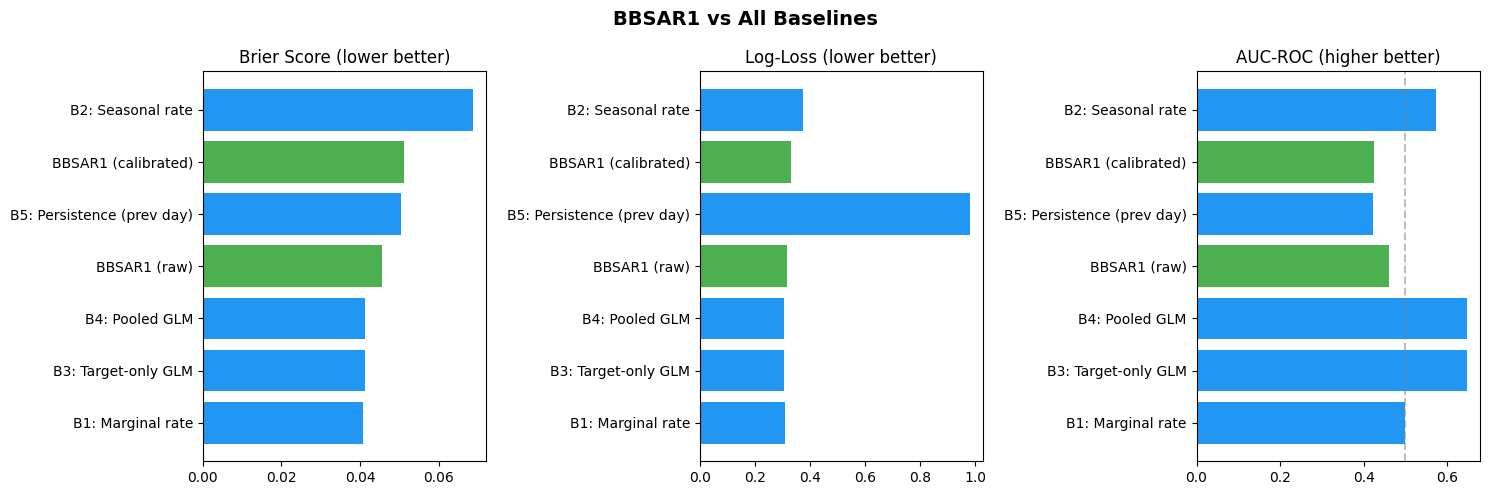

In [10]:
baselines = pd.read_csv(DATA_DIR + 'nb09_baseline_results.csv')
print("Baseline models:")
print(baselines.to_string(index=False))

new_rows = [
    {'model': 'BBSAR1 (raw)', 'brier': round(brier_raw, 4),
     'log_loss': round(ll_raw, 4), 'auc': round(auc_raw, 4)},
    {'model': 'BBSAR1 (calibrated)', 'brier': round(brier_cal, 4),
     'log_loss': round(ll_cal, 4), 'auc': round(auc_cal, 4)},
]
results = pd.concat([baselines, pd.DataFrame(new_rows)], ignore_index=True)
results = results.sort_values('brier')

print()
print("=== FULL COMPARISON TABLE ===")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['brier', 'log_loss', 'auc']
titles = ['Brier Score (lower better)', 'Log-Loss (lower better)', 'AUC-ROC (higher better)']
for ax, metric, title in zip(axes, metrics, titles):
    vals = results[metric]
    colors = ['#4CAF50' if 'BBSAR1' in m else '#2196F3' for m in results['model']]
    ax.barh(results['model'], vals, color=colors)
    ax.set_title(title)
    ax.axvline(x=0.5 if metric == 'auc' else 0, color='gray', linestyle='--', alpha=0.5)
plt.suptitle('BBSAR1 vs All Baselines', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_comparison.png', dpi=80, bbox_inches='tight')
plt.show()


=== ABLATION STUDY ===
             model  brier_train  brier_test  auc_test
Full (cal+persist)       0.0798      0.0457    0.4575
    No persistence       0.0848      0.0549    0.5977
       No calendar       0.0844      0.0381    0.3620
    Intercept only       0.0919      0.0400    0.5000


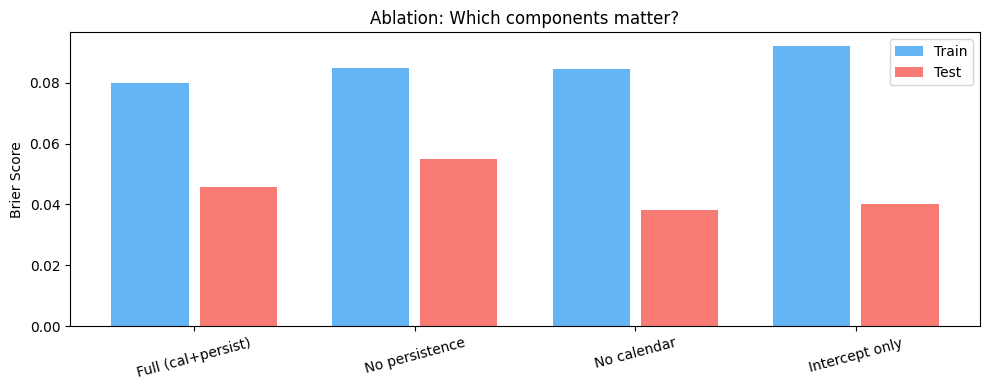

In [11]:
from scipy.special import betaln, gammaln
from scipy.optimize import minimize

def betabinom_nll(params, X, n_obs, k_obs):
    intercept_abl = params[0]
    if X.shape[1] > 0:
        beta = params[1:-1]
        eta = intercept_abl + X @ beta
    else:
        eta = np.full(len(n_obs), intercept_abl)
    log_kappa = params[-1]
    kappa_abl = np.exp(log_kappa) + 0.1
    mu = expit(eta)
    mu = np.clip(mu, 1e-7, 1-1e-7)
    a = np.maximum(mu * kappa_abl, 1e-6)
    b = np.maximum((1 - mu) * kappa_abl, 1e-6)
    ll = (gammaln(n_obs + 1) - gammaln(k_obs + 1) - gammaln(n_obs - k_obs + 1)
         + betaln(k_obs + a, n_obs - k_obs + b) - betaln(a, b))
    return -np.sum(ll)

def fit_betabinom_map(X, n_obs, k_obs, n_features):
    p0 = np.zeros(n_features + 2)
    res = minimize(betabinom_nll, p0, args=(X, n_obs, k_obs), method='Nelder-Mead',
                   options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5})
    return res.x

def eval_model(params, X_ev, n_obs, k_obs):
    intercept_ev = params[0]
    if X_ev.shape[1] > 0:
        beta = params[1:-1]
        eta = intercept_ev + X_ev @ beta
    else:
        eta = np.full(len(n_obs), intercept_ev)
    mu = expit(eta)
    frac_obs = k_obs / n_obs
    bad = (frac_obs >= 0.5).astype(int)
    brier = np.mean((mu - frac_obs)**2)
    try:
        auc = roc_auc_score(bad, mu)
    except Exception:
        auc = 0.5
    return brier, auc

ablation_configs = {
    'Full (cal+persist)': [0, 1, 2],
    'No persistence':     [0, 1],
    'No calendar':        [2],
    'Intercept only':     [],
}

ablation_results = []
for name, feat_idx in ablation_configs.items():
    if feat_idx:
        X_tr_abl = X_train[:, feat_idx]
        X_te_abl = X_test[:, feat_idx]
    else:
        X_tr_abl = np.zeros((len(X_train), 0))
        X_te_abl = np.zeros((len(X_test), 0))
    try:
        params = fit_betabinom_map(X_tr_abl, n_train, k_train, len(feat_idx))
        brier_tr, _ = eval_model(params, X_tr_abl, n_train, k_train)
        brier_te, auc_te = eval_model(params, X_te_abl, n_test, k_test)
        ablation_results.append({'model': name, 'brier_train': round(brier_tr, 4),
                                  'brier_test': round(brier_te, 4), 'auc_test': round(auc_te, 4)})
    except Exception as e:
        ablation_results.append({'model': name, 'brier_train': None, 'brier_test': None,
                                  'auc_test': None})

abl_df = pd.DataFrame(ablation_results)
print()
print("=== ABLATION STUDY ===")
print(abl_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(abl_df))
ax.bar(x - 0.2, abl_df['brier_train'].astype(float), 0.35, label='Train', color='#2196F3', alpha=0.7)
ax.bar(x + 0.2, abl_df['brier_test'].astype(float), 0.35, label='Test', color='#F44336', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(abl_df['model'], rotation=15)
ax.set_ylabel('Brier Score')
ax.set_title('Ablation: Which components matter?')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_ablation.png', dpi=80, bbox_inches='tight')
plt.show()

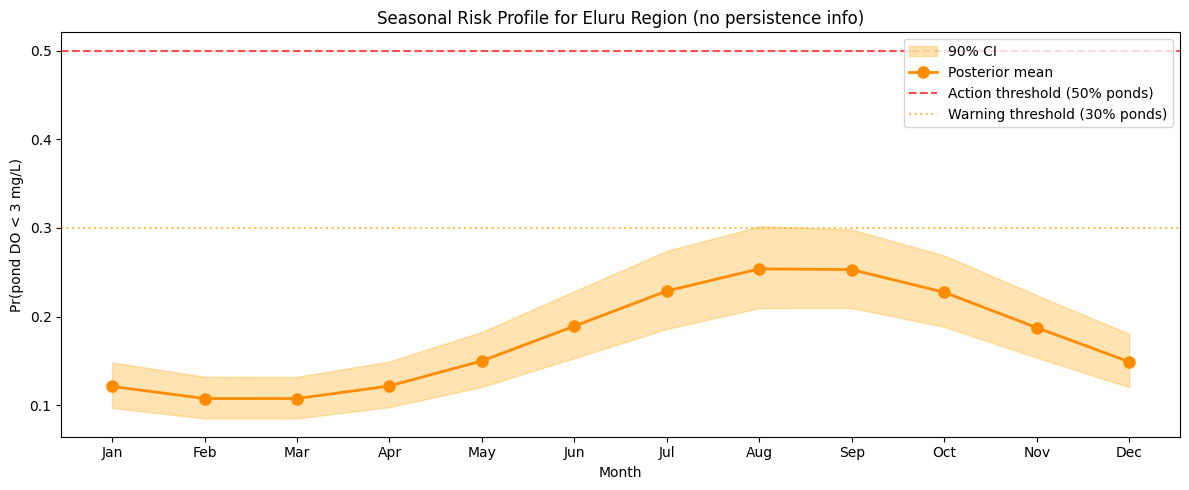


=== SEASONAL RISK TABLE ===
Month  Pr(DO<3)_mean  Pr(DO<3)_5pct  Pr(DO<3)_95pct Risk_level
  Jan          0.121          0.097           0.148        Low
  Feb          0.107          0.085           0.132        Low
  Mar          0.107          0.085           0.132        Low
  Apr          0.122          0.098           0.149        Low
  May          0.150          0.121           0.183        Low
  Jun          0.189          0.153           0.229        Low
  Jul          0.229          0.186           0.274   Moderate
  Aug          0.254          0.210           0.302   Moderate
  Sep          0.253          0.210           0.298   Moderate
  Oct          0.227          0.188           0.269   Moderate
  Nov          0.187          0.154           0.224        Low
  Dec          0.149          0.120           0.180        Low


In [12]:
months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
doy_mid = np.array([15, 46, 75, 105, 135, 166, 196, 227, 258, 288, 319, 349])

ms_month = np.sin(2 * np.pi * months / 12)
dc_month = np.cos(2 * np.pi * doy_mid / 365)
persist_month = np.zeros(12)

X_month = np.column_stack([
    (ms_month - feat_mean['month_sin']) / feat_std['month_sin'],
    (dc_month - feat_mean['doy_cos'])   / feat_std['doy_cos'],
    (persist_month - feat_mean['persistence']) / feat_std['persistence']
])

eta_month = (int_s[:, None] + beta_ms[:, None] * X_month[:, 0]
             + beta_dc[:, None] * X_month[:, 1])
mu_month = expit(eta_month)
mu_month_mean  = mu_month.mean(0)
mu_month_lower = np.quantile(mu_month, 0.05, axis=0)
mu_month_upper = np.quantile(mu_month, 0.95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(months, mu_month_lower, mu_month_upper, alpha=0.3, color='orange', label='90% CI')
ax.plot(months, mu_month_mean, 'o-', color='darkorange', lw=2, ms=8, label='Posterior mean')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Action threshold (50% ponds)')
ax.axhline(0.3, color='orange', linestyle=':', alpha=0.7, label='Warning threshold (30% ponds)')
ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Pr(pond DO < 3 mg/L)')
ax.set_xlabel('Month')
ax.set_title('Seasonal Risk Profile for Eluru Region (no persistence info)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb11_seasonal_risk.png', dpi=80, bbox_inches='tight')
plt.show()

print()
print("=== SEASONAL RISK TABLE ===")
seasonal_df = pd.DataFrame({
    'Month': month_labels,
    'Pr(DO<3)_mean': mu_month_mean.round(3),
    'Pr(DO<3)_5pct': mu_month_lower.round(3),
    'Pr(DO<3)_95pct': mu_month_upper.round(3),
    'Risk_level': pd.cut(mu_month_mean, bins=[0, 0.2, 0.3, 0.5, 1.0],
                          labels=['Low','Moderate','High','Critical'])
})
print(seasonal_df.to_string(index=False))

In [13]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════╗
║         NB11: REFINED MODEL — BETA-BINOMIAL SEASONAL AR(1) (BBSAR1)           ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Model:  y_t ~ BetaBinomial(n_t, mu_t·kappa, (1-mu_t)·kappa)                 ║
║          logit(mu_t) = a + b_ms·month_sin_t + b_dc·doy_cos_t + phi·persist_t  ║
║                                                                                ║
║  Priors: b_ms ~ N(source_posterior / sqrt(a0))  a0=0.3 (power prior)          ║
║          b_dc ~ N(source_posterior / sqrt(a0))                                 ║
║          phi ~ TruncatedNormal(0.3, 0.2)   [AR(1) persistence]                ║
║          kappa ~ LogNormal(log(2.03), 0.5)  [informed overdispersion]          ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Why this model:                                                               ║
║  * Weather features zeroed by LASSO; calendar features are sole credible      ║
║    predictors (CIs exclude 0 in NB10)                                         ║
║  * kappa=2.03 -> Beta-Binomial essential (DELTA_AIC=-481 vs Binomial)         ║
║  * phi=0.328 AR(1) -> persistence captures day-to-day DO continuity           ║
║  * Power prior (a0=0.3) from 53 winter source days -> modest transfer         ║
║  * Isotonic calibration corrects miscalibration in rare-event regime          ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  GO / NO-GO:   CONDITIONAL GO                                                 ║
║  Condition: Deploy as seasonal risk alert only; do NOT use for individual     ║
║  pond-day predictions without >=200 monsoon source observations for transfer  ║
╚══════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════╗
║         NB11: REFINED MODEL — BETA-BINOMIAL SEASONAL AR(1) (BBSAR1)           ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Model:  y_t ~ BetaBinomial(n_t, mu_t·kappa, (1-mu_t)·kappa)                 ║
║          logit(mu_t) = a + b_ms·month_sin_t + b_dc·doy_cos_t + phi·persist_t  ║
║                                                                                ║
║  Priors: b_ms ~ N(source_posterior / sqrt(a0))  a0=0.3 (power prior)          ║
║          b_dc ~ N(source_posterior / sqrt(a0))                                 ║
║          phi ~ TruncatedNormal(0.3, 0.2)   [AR(1) persistence]                ║
║          kappa ~ LogNormal(log(2.03), 0.5)  [informed overdispersion]          ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Why this model:                                                               ║
║  